In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(220, 220)


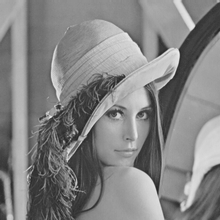

True

In [ ]:
# Colab資料夾設定方法
# !pip install google.colab # 如未安裝則需進行安裝
import os
import cv2
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

# !!提醒需手動執行授權
os.chdir('/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Ref Image/')  # 切換該目錄
os.listdir()  # 確認目錄內容

# Check if the file exists before reading it.
# Print an error message and exit if it does not.
image_path = "Lenna_(test_image).png"
if not os.path.exists(image_path):
    print(F"Error: Image file not found: {image_path}")
    exit()

image = cv2.imread(image_path, 0)
print(image.shape)
cv2_imshow(image)

# 儲存圖片
cv2.imwrite('resize.jpg', image)


In [ ]:
from IPython.display import Image

# 顯示圖片
Image("/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Lesson Practice/20250226_094001.jpg")


Output hidden; open in https://colab.research.google.com to view.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
請輸入想量化的位元數(1~8): 3
原灰階影像:


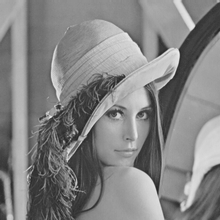

3 bit 量化影像:


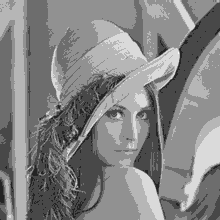

In [ ]:
import cv2
import numpy as np
import os
from google.colab import drive
# 專門用來在 Colab 顯示影像
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')

def quantize_image_opencv(gray_img, bits):
    levels = 2 ** bits
    # 先正規化到 [0,1]
    normalized = gray_img / 255.0
    # 離散化到 0~(levels-1)
    quantized = np.round(normalized * (levels - 1))
    # 放大回 0~255
    quantized_8u = (quantized / (levels - 1) * 255).astype(np.uint8)
    return quantized_8u

def main():
    # !!提醒需手動執行授權
    os.chdir('/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Ref Image/')  # 切換該目錄
    os.listdir()  # 確認目錄內容

    image_path = "Lenna_(test_image).png"
    if not os.path.exists(image_path):
        print(f"Error: Image file not found: {image_path}")
        exit()

    # 以灰階模式讀取
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    b = int(input("請輸入想量化的位元數(1~8): "))

    # 量化
    quantized_img = quantize_image_opencv(img, b)

    # 在 Colab 顯示影像需用 cv2_imshow
    print("原灰階影像:")
    cv2_imshow(img)
    print(f"{b} bit 量化影像:")
    cv2_imshow(quantized_img)

if __name__ == '__main__':
    main()


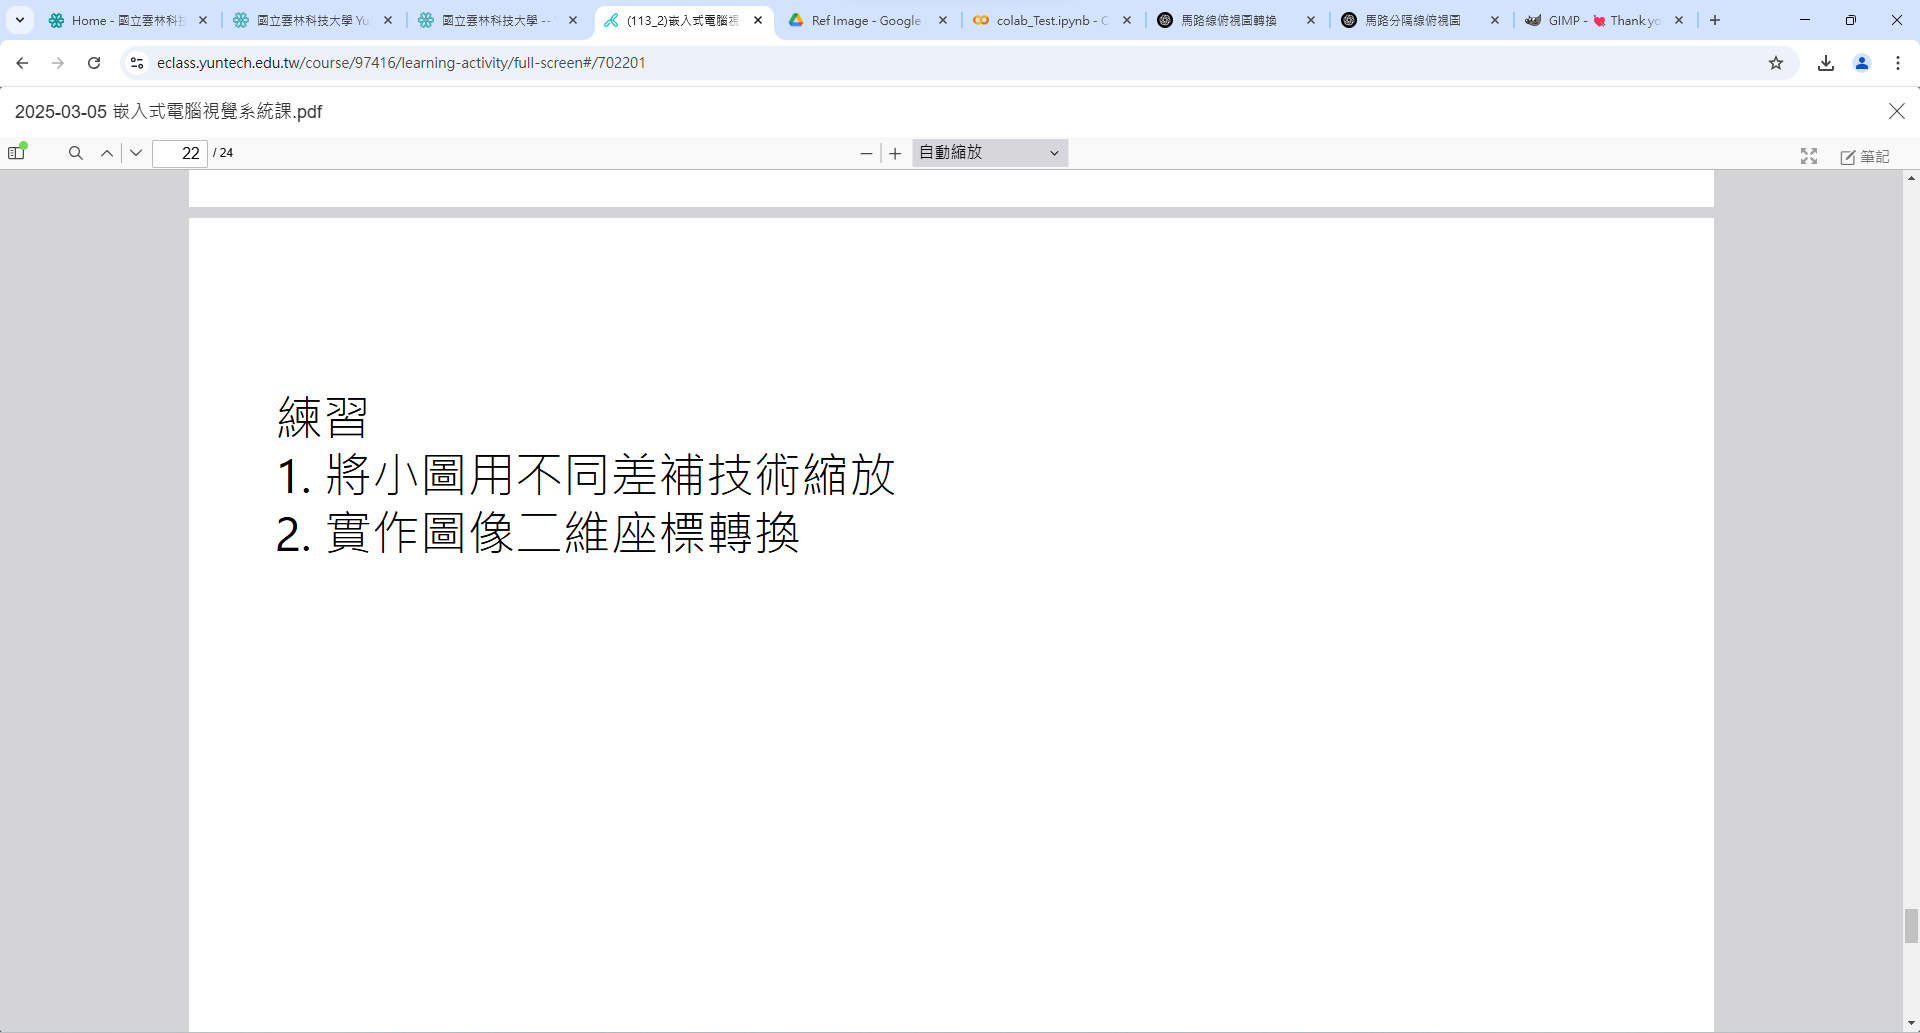

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


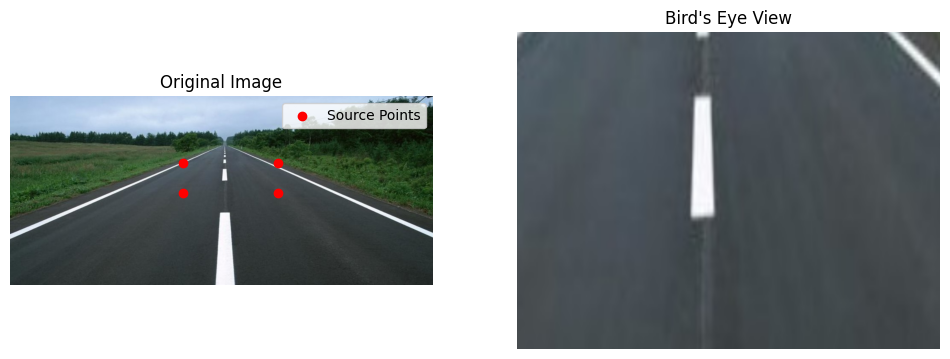

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Ref Image/')  # 切換該目錄
os.listdir()  # 確認目錄內容

image_path = "/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Ref Image/Lane.jpg"
if not os.path.exists(image_path):
    print(f"Error: Image file not found: {image_path}")
    exit()

# 讀取原始影像
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # 轉換為 RGB 格式以供 Matplotlib 顯示

# 設定原圖像中 ROI 的四個頂點 (以 [x, y] 格式)
pts_src = np.float32([
    [507, 194],  # 左上
    [784, 194],  # 右上
    [507, 284],  # 左下
    [784, 284]   # 右下
])

# 設定俯視圖中對應的四個頂點
W, H = 800, 600  # 定義輸出影像大小
pts_dst = np.float32([
    [0, 0],    # 左上
    [W, 0],    # 右上
    [0, H],    # 左下
    [W, H]     # 右下
])

# 計算透視變換矩陣 M
M = cv2.getPerspectiveTransform(pts_src, pts_dst)

# 將影像扭正為俯視圖
warped = cv2.warpPerspective(image, M, (W, H))

# 使用 Matplotlib 顯示原始影像與俯視影像
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 顯示原始影像
ax[0].imshow(image)
ax[0].scatter(pts_src[:, 0], pts_src[:, 1], c='red', marker='o', label='Source Points')
ax[0].set_title("Original Image")
ax[0].legend()
ax[0].axis("off")

# 顯示俯視影像
ax[1].imshow(warped)
ax[1].set_title("Bird's Eye View")
ax[1].axis("off")

# 顯示圖片
plt.show()


In [3]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.1 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Unins

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


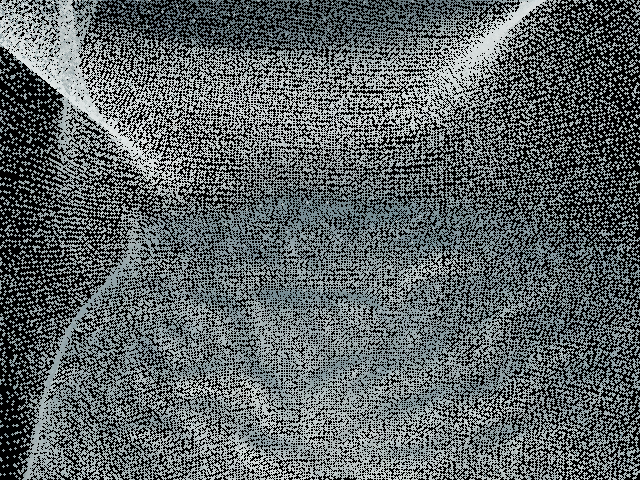

In [8]:
import open3d as o3d
import cv2
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

image_path = "/content/drive/MyDrive/雲科大/崁入式電腦視覺系統/Ref Image/david RGB.ply"

# 讀取 ply 點雲文件
pcd = o3d.io.read_point_cloud(image_path)
points = np.asarray(pcd.points)    # 點雲的 3D 座標 (N, 3)
colors = np.asarray(pcd.colors)      # 點雲的 RGB 顏色 (N, 3)，通常範圍在 [0,1]

# 定義相機內參數矩陣 (這裡的數值僅為示例，可根據實際情況調整)
fx = 525.0  # 水平焦距
fy = 525.0  # 垂直焦距
cx = 319.5  # 影像主點 (x)
cy = 239.5  # 影像主點 (y)
camera_matrix = np.array([[fx, 0, cx],
                          [0, fy, cy],
                          [0,  0,  1]])

# 設定相機外參數，這裡以無旋轉、無平移作示例
# 若有旋轉和平移，可依據實際情況修改 rvec 與 tvec 的數值
rvec = np.array([0, 0, 0], dtype=np.float64)  # 旋轉向量
tvec = np.array([0, 0, 0], dtype=np.float64)  # 平移向量

# OpenCV 的 projectPoints 函數需要 rvec 與 tvec 為 (3,1) 向量
rvec = rvec.reshape((3,1))
tvec = tvec.reshape((3,1))

# 利用 cv2.projectPoints 將 3D 點投影到 2D 影像平面
image_points, _ = cv2.projectPoints(points, rvec, tvec, camera_matrix, None)
image_points = image_points.reshape(-1, 2)

# 建立一張空的影像 (假設影像大小為 640x480)
image = np.zeros((480, 640, 3), dtype=np.uint8)

# 將投影後的點繪製到影像上
for pt, color in zip(image_points, colors):
    x, y = int(pt[0]), int(pt[1])
    if 0 <= x < 640 and 0 <= y < 480:
        # 將顏色從 [0,1] 轉換到 [0,255]
        col = (color * 255).astype(np.uint8).tolist()
        cv2.circle(image, (x, y), radius=1, color=col, thickness=-1)

# 儲存並顯示結果影像
cv2.imwrite("projected_image.jpg", image)

# 在 Google Colab 中顯示影像 (Colab 需要使用 cv2_imshow)
from google.colab.patches import cv2_imshow
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()

2025.03.12  
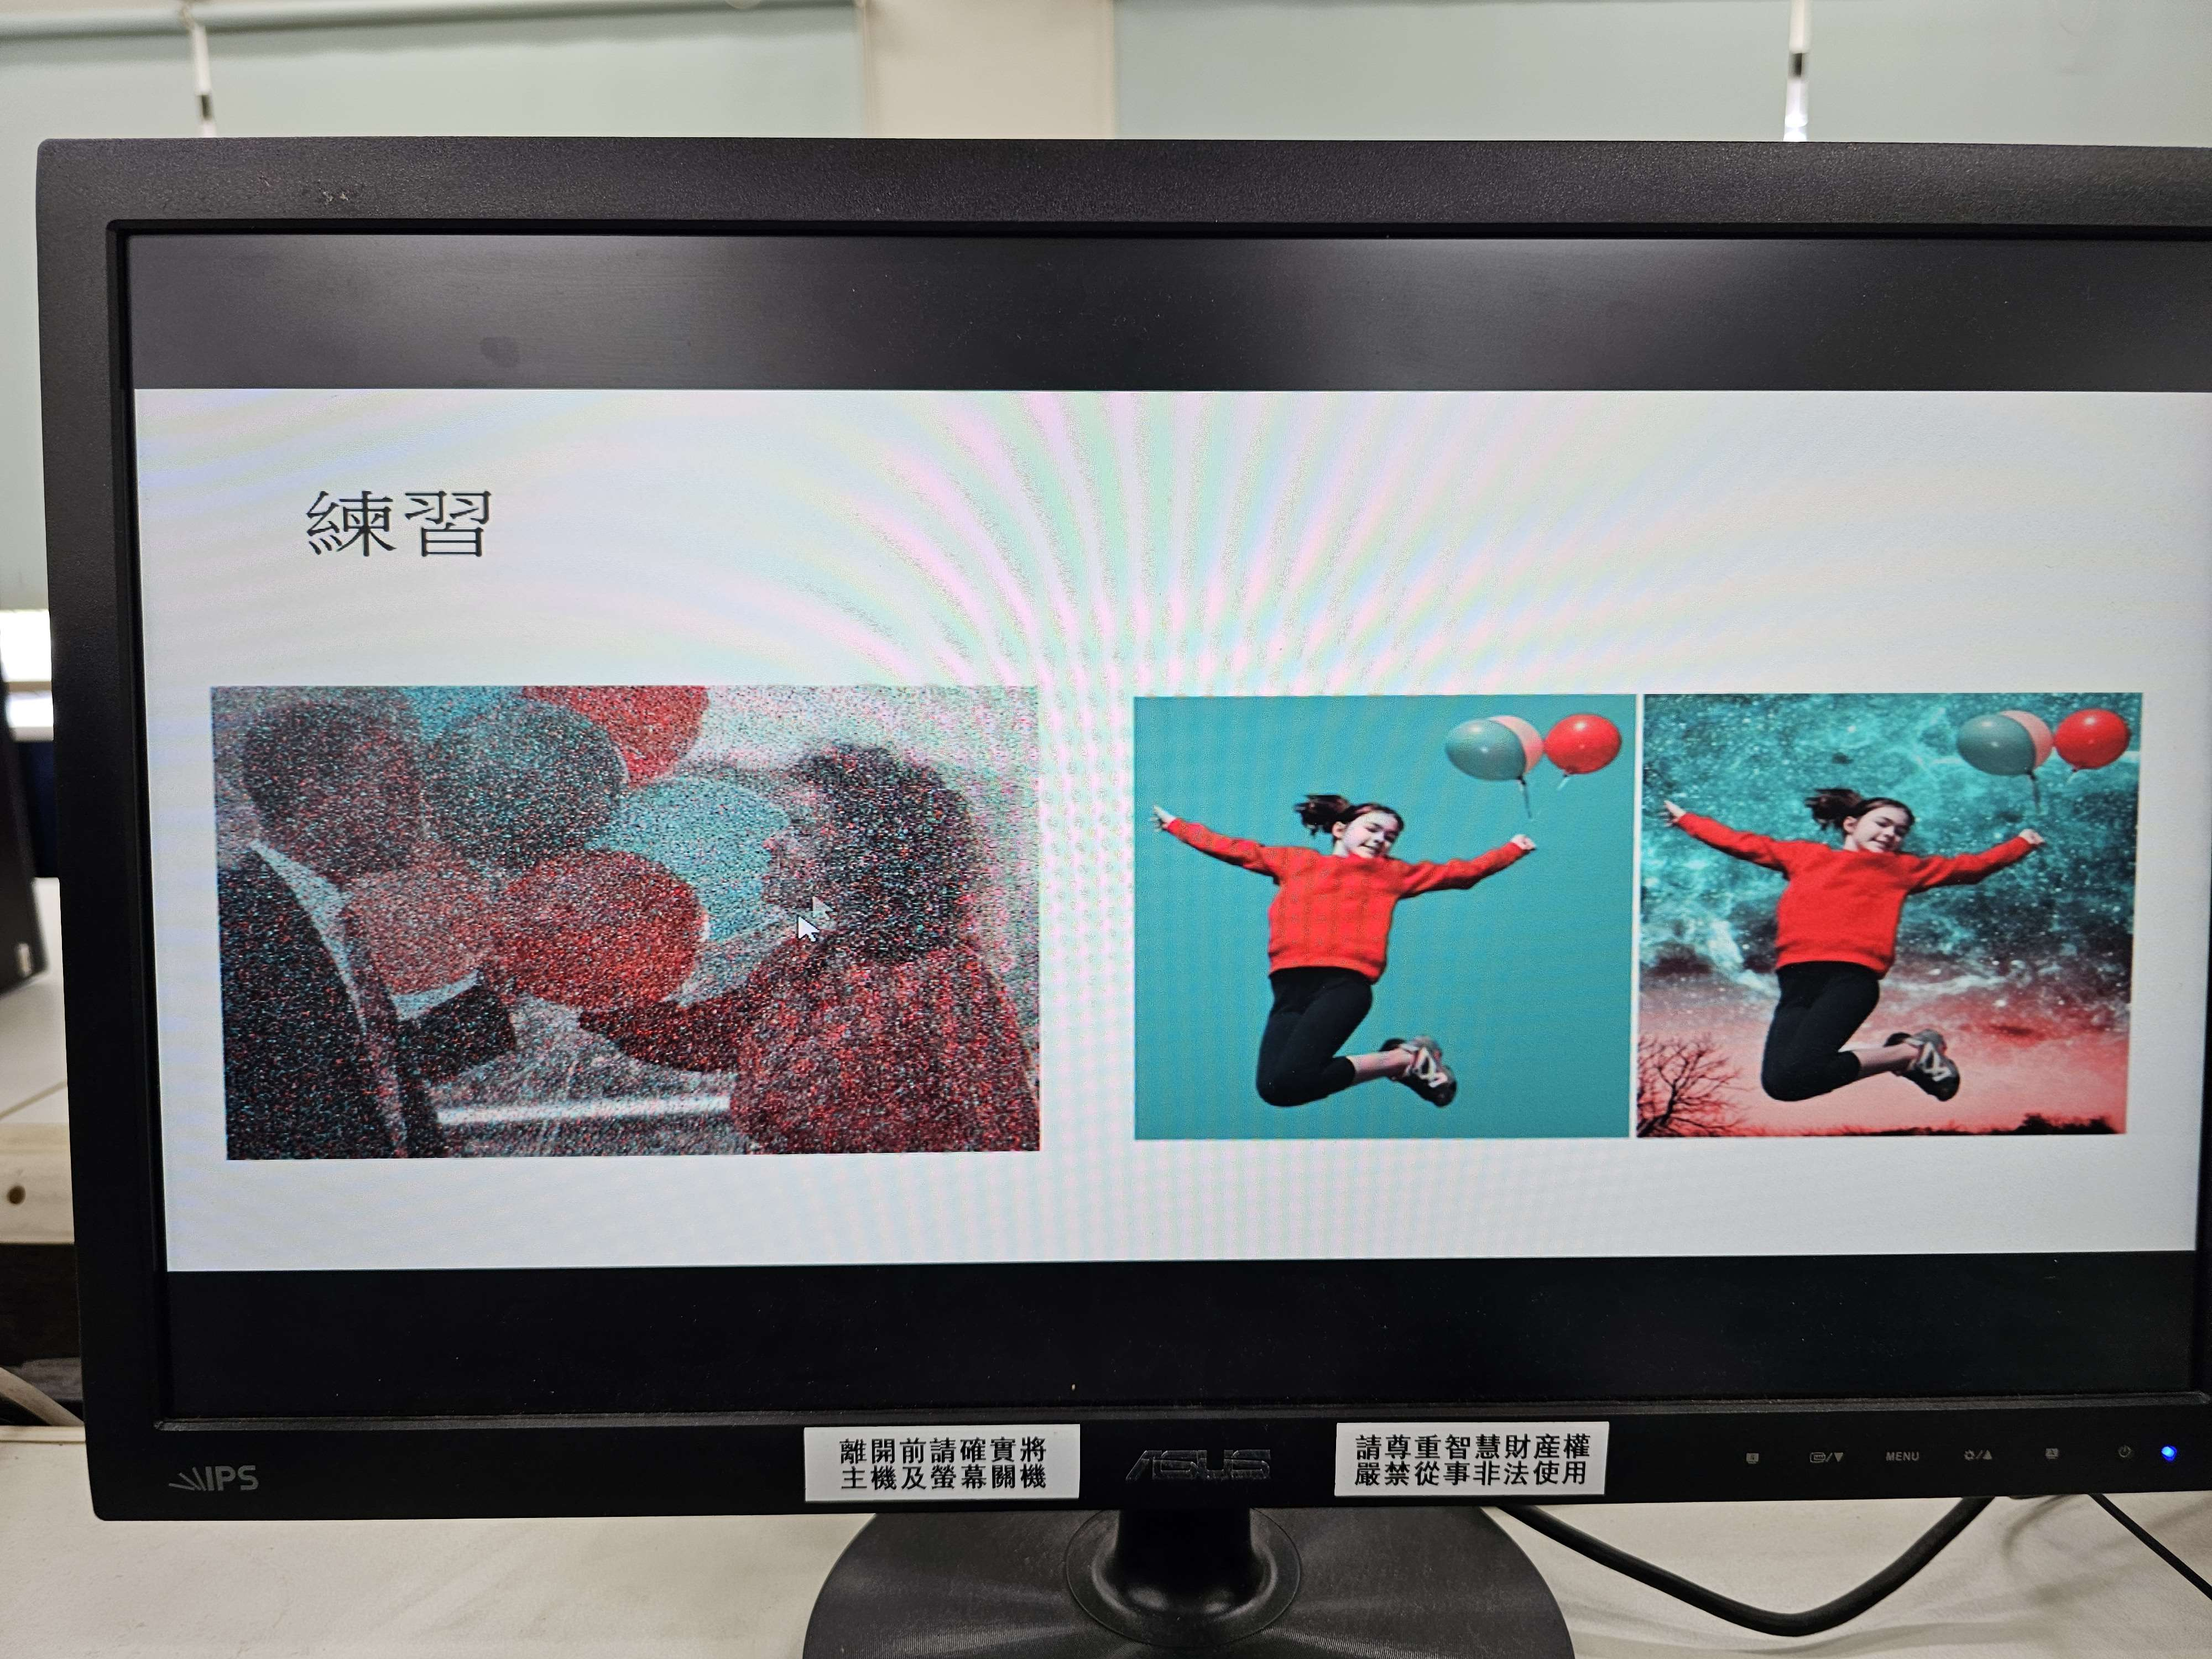

- homework 1: 彩色雜訊抑制  
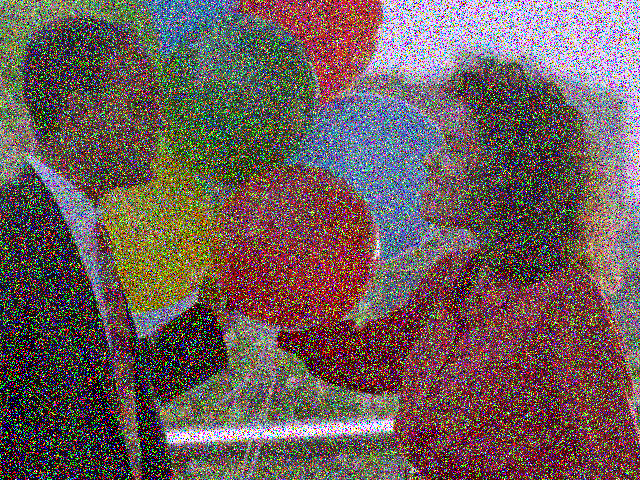

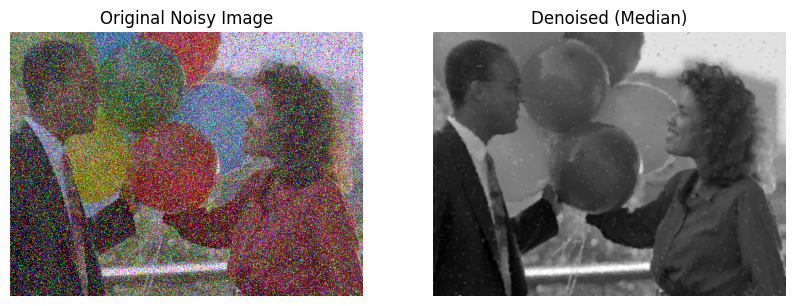

In [14]:
import matplotlib.pyplot as plt
from skimage import io, img_as_ubyte
from skimage.filters import median
from skimage.morphology import disk
from skimage.color import rgb2gray

# 1. 讀取影像
imgPath = r"./Ref Image/balloons_noisy.png"
img = io.imread(imgPath)  # 請換成你的檔名

# 2. 轉成灰階並進行中值濾波
gray_img = rgb2gray(img)
denoised = median(gray_img, disk(3))

# 3. 將浮點影像轉換成 8 位元格式
denoised_u8 = img_as_ubyte(denoised)

# 4. 儲存處理後的結果
io.imsave('balloons_denoised_skimage.png', denoised_u8)

# 5. 顯示對比結果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img)
ax1.set_title('Original Noisy Image')
ax1.axis('off')

ax2.imshow(denoised, cmap='gray')
ax2.set_title('Denoised (Median)')
ax2.axis('off')

plt.show()


- homework 2: 背景分割變換  


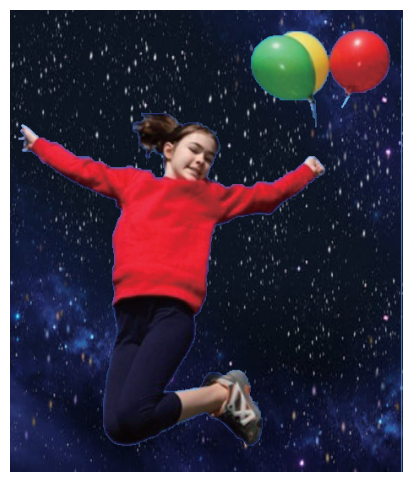

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 讀取前景圖片（人物）
foreground_path = r"./Ref Image/change_background.png"
foreground = cv2.imread(foreground_path)

# 轉換為 RGB
foreground_rgb = cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)

# 建立遮罩
mask = np.zeros(foreground.shape[:2], np.uint8)

# 建立背景與前景模型
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# 設定人物的初始區域 (手動調整矩形，以更好地擬合人物)
height, width = foreground.shape[:2]
rect = (10, 10, width-10, height-10)  # 矩形框住前景

# 使用 GrabCut 進行背景去除
cv2.grabCut(foreground_rgb, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# 轉換 mask 來獲取前景
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

# 去除背景
foreground_no_bg = foreground * mask2[:, :, np.newaxis]

# 讀取背景圖片並調整大小
background_path = r"./Ref Image/pngtree-cosmic-space-starry-sky-background-image_351018.jpg"
background = cv2.imread(background_path)
background = cv2.resize(background, (foreground.shape[1], foreground.shape[0]))

# 應用反向遮罩到背景
background_masked = background * (1 - mask2[:, :, np.newaxis])

# 合併前景與背景
result = background_masked + foreground_no_bg

# # 儲存結果
# output_path = "/mnt/data/replaced_background_grabcut.png"
# cv2.imwrite(output_path, result)

# 轉換圖片為 RGB 格式以顯示
segmented_img_rgb = cv2.cvtColor(foreground_no_bg, cv2.COLOR_BGR2RGB)
result_img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# 顯示結果
fig, axes = plt.subplots(figsize=(12, 6))

# 顯示分割後的圖片
axes.imshow(result_img_rgb)
axes.axis("off")
plt.show()


2025-04-23 上課練習

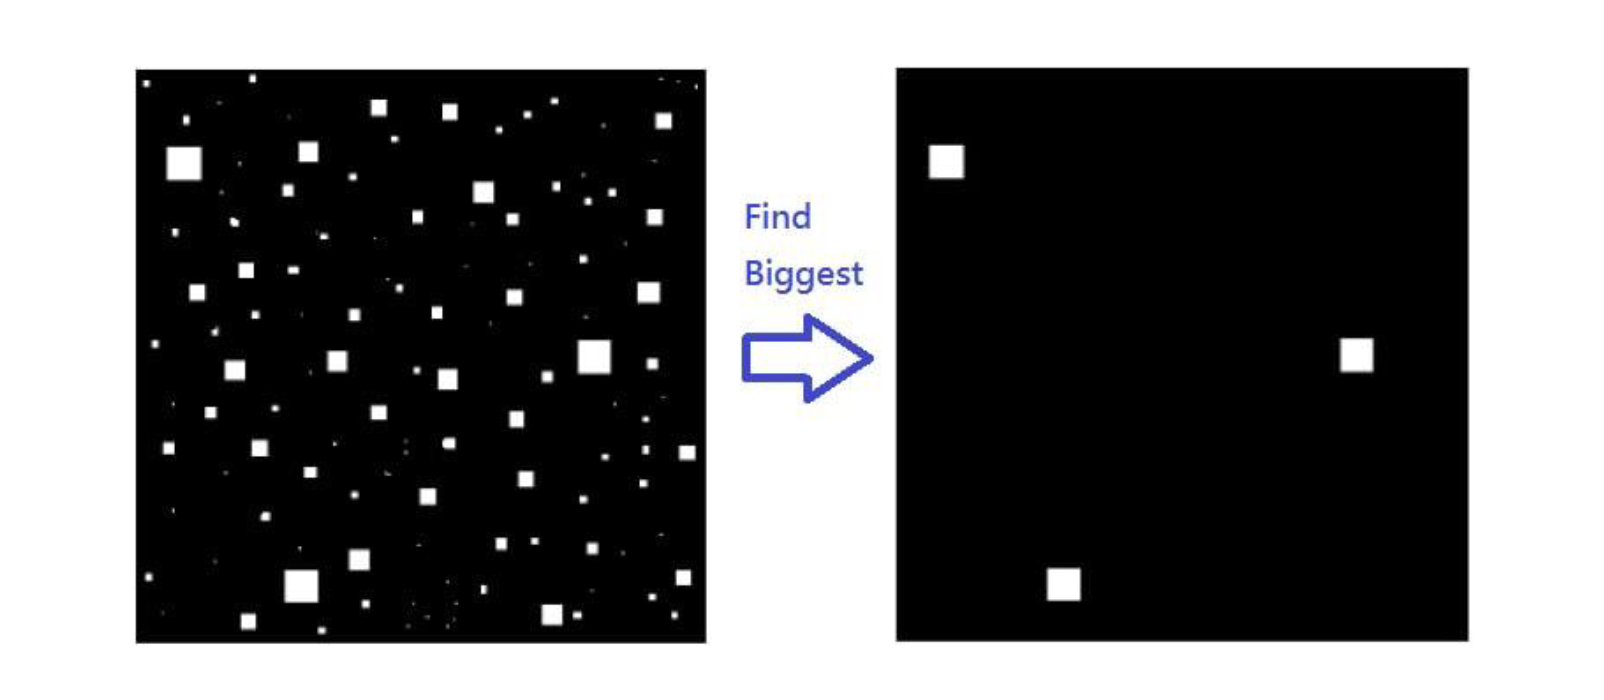

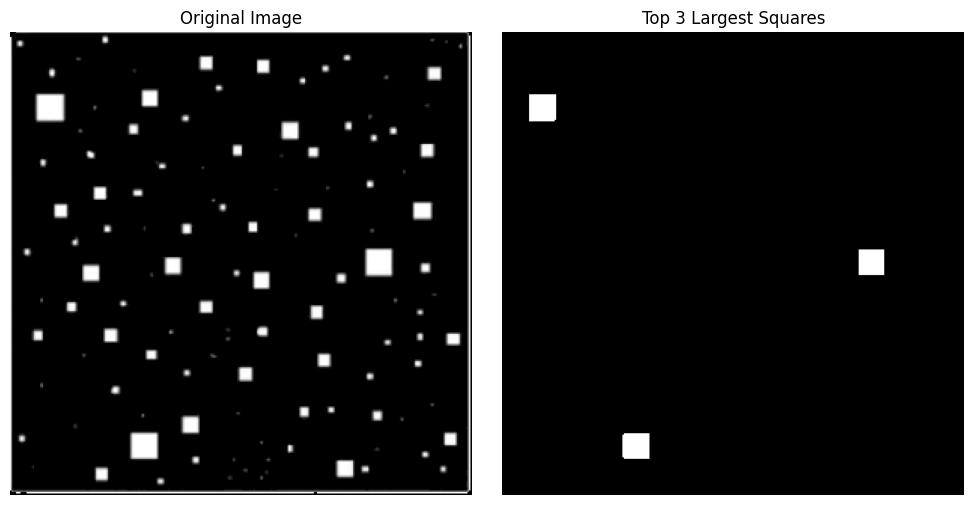

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------- 參數設定 -------------------
INPUT_PATH = r'D:\KenChen\YunTech\Embedded-Computer-Vision-System\Program\Ref Image\Clipped_image_20250423_100937.png'
KEEP_N     = 3      # 想保留最大的 N 個方塊
MIN_SIZE   = 50     # 過濾過小區域的最小面積（可調）

# 1. 讀圖、轉灰階、二值化
img = cv2.imread(INPUT_PATH, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Cannot read image, check path: {INPUT_PATH}")
_, bw = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 2. 找外部輪廓
contours, _ = cv2.findContours(
    bw,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 3. 篩掉過小或非正方形區域，並依面積排序
valid = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < MIN_SIZE:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    ratio = w / float(h)
    # 僅保留近似正方形
    if not (0.7 < ratio < 1.3):
        continue
    valid.append((cnt, area))

valid_sorted = sorted(valid, key=lambda x: x[1], reverse=True)
top_contours = [c for c, _ in valid_sorted[:KEEP_N]]

# 4. 在黑底上畫出這些最大方塊
canvas = np.zeros_like(bw)
cv2.drawContours(canvas, top_contours, -1, color=255, thickness=cv2.FILLED)

# 5. 用 Matplotlib 並排顯示（英文標題）
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(canvas, cmap='gray')
axes[1].set_title(f'Top {KEEP_N} Largest Squares')
axes[1].axis('off')

plt.tight_layout()
plt.show()


**2025.05.14 上課內容**  
**猜拳辨識(基礎CNN訓練)**

**如果要訓練模型，package版本必須符合Chaquopy的版本**  
**https://chaquo.com/pypi-7.0/**  

**使用Kaggle Dataset**  
**https://www.kaggle.com/datasets/ardamavi/sign-language-digits-dataset**

**他跑出來有10種手勢**

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import os
import numpy as np
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPool2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------------------
# 1. Load and filter dataset for RPS (rock=0, scissors=2, paper=5)
# ------------------------------------------------------------------------------
# Load original digits dataset (shape: N, 64,64,1) and one-hot labels (N,10)
x_all = np.load('./Ref Image/Sign-language-digits-dataset/X.npy')  # (N,64,64)
y_all = np.load('./Ref Image/Sign-language-digits-dataset/Y.npy')  # (N,10)

y_labels = np.argmax(y_all, axis=1)  # Convert one-hot to integer labels (0-9)

# Focus on classes 0 (rock), 2 (scissors), 5 (paper)
selected = [0, 2, 5]
mask = np.isin(y_labels, selected)
X = x_all[mask]  # Filtered images
y = y_labels[mask]  # Filtered labels

# Remap labels to 0,1,2 for RPS
mapping = {0: 0, 2: 1, 5: 2}
y_mapped = np.array([mapping[val] for val in y])

# One-hot encode into 3 classes
Y = to_categorical(y_mapped, num_classes=3)

# Reshape X to add channel and normalize
X = X.reshape(-1, 64, 64, 1).astype('float32') / 255.0

print(f"Filtered dataset: {X.shape[0]} samples. X shape: {X.shape}, Y shape: {Y.shape}")

# ------------------------------------------------------------------------------
# 2. Split into train and test sets
# ------------------------------------------------------------------------------
test_size = 0.25
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=test_size, random_state=42, stratify=Y
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# ------------------------------------------------------------------------------
# 3. Build 3-class CNN model
# ------------------------------------------------------------------------------
model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 1)),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPool2D((2, 2)),
    Dropout(0.4),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPool2D((2, 2)),
    Dropout(0.4),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPool2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output layer for 3 classes: rock, scissors, paper
    Dense(3, activation='softmax')
])
model.summary()

# ------------------------------------------------------------------------------
# 4. Compile model
# ------------------------------------------------------------------------------
optimizer = Adam(lr=1e-3, beta_1=0.9, beta_2=0.99)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------------------------
# 5. Set up callback to stop when validation accuracy > 99%
# ------------------------------------------------------------------------------
class EarlyStopByAcc(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy', 0) > 0.99:
            print(f"\nReached 99% val_accuracy at epoch {epoch+1}, stopping training.")
            self.model.stop_training = True

callbacks = [EarlyStopByAcc()]

# ------------------------------------------------------------------------------
# 6. Train the model
# ------------------------------------------------------------------------------
history = model.fit(
    X_train, Y_train,
    epochs=200,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    batch_size=32
)

# ------------------------------------------------------------------------------
# 7. Export to SavedModel and TFLite
# ------------------------------------------------------------------------------
export_dir = './tmp/rps_save_model'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

# Save TensorFlow SavedModel
tf.saved_model.save(model, export_dir)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
tflite_model = converter.convert()

# Write TFLite file
tflite_path = pathlib.Path('./tmp/rps.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved to {tflite_path}")


Filtered dataset: 618 samples. X shape: (618, 64, 64, 1), Y shape: (618, 3)
Training samples: 463, Test samples: 155
Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 64, 64, 32)        320       
_________________________________________________________________
batch_normalization_2 (Batch (None, 64, 64, 32)        128       
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 32, 32, 32)        0         
_________________________________________________________________
dropout_8 (Dropout)          (None, 32, 32, 32)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 32, 32, 64)        18496     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 16, 16, 64)        0         
___

d:\Miniconda\envs\tf-gpu-palm\lib\site-packages\keras\optimizer_v2\optimizer_v2.py:355: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  warnings.warn(


Epoch 1/200
15/15 [==============================] - 4s 24ms/step - loss: 1.1002 - accuracy: 0.3197 - val_loss: 1.0986 - val_accuracy: 0.3355
Epoch 2/200
15/15 [==============================] - 0s 11ms/step - loss: 1.0990 - accuracy: 0.3045 - val_loss: 1.0987 - val_accuracy: 0.3290
Epoch 3/200
15/15 [==============================] - 0s 11ms/step - loss: 1.0978 - accuracy: 0.3607 - val_loss: 1.0985 - val_accuracy: 0.3355
Epoch 4/200
15/15 [==============================] - 0s 11ms/step - loss: 1.0729 - accuracy: 0.4082 - val_loss: 1.1093 - val_accuracy: 0.3290
Epoch 5/200
15/15 [==============================] - 2s 162ms/step - loss: 0.8852 - accuracy: 0.5702 - val_loss: 1.0435 - val_accuracy: 0.7161
Epoch 6/200
15/15 [==============================] - 0s 12ms/step - loss: 0.6725 - accuracy: 0.6695 - val_loss: 1.0816 - val_accuracy: 0.5613
Epoch 7/200
15/15 [==============================] - 0s 11ms/step - loss: 0.5516 - accuracy: 0.7646 - val_loss: 1.1103 - val_accuracy: 0.4581
Epoch

INFO:tensorflow:Assets written to: ./tmp/rps_save_model\assets


TFLite model saved to tmp\rps.tflite
